# Качество данных лабораторной работы 5

Вариант 3: 100 цитат и сведения об авторах. Ещё 304 книги собраны с Books to Scrape.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from analyze import analyze
from smoke_check import check

report = analyze()
assert report['rows'] >= 300
assert report['required_empty_share'] == 0
assert all(info['duplicates'] == 0 for info in report['tables'].values())
display(pd.DataFrame({name: {'Строк': info['rows'], 'Уникальных ключей': info['unique_keys'], 'Пустых обязательных': info['required_empty_rows']} for name,info in report['tables'].items()}).T)

{"rows": 404, "tables": {"quotes": 100, "books": 304}, "required_empty_share": 0.0}


,Строк,Уникальных ключей,Пустых обязательных
quotes,100,100,0
books,304,304,0


## Полнота и типы

In [2]:
display(pd.read_csv('completeness.csv'))
display(pd.DataFrame(report['business_rule_violations'].items(), columns=['Проверка', 'Нарушений']))
assert all(value == 0 for value in report['business_rule_violations'].values())

,table,field,completeness_percent
0,quotes,key,100.0
1,quotes,quote,100.0
2,quotes,author,100.0
3,quotes,tags,100.0
4,quotes,author_url,100.0
5,quotes,birth_date,100.0
6,quotes,birth_place,100.0
7,quotes,biography,100.0
8,quotes,url,100.0
9,books,key,100.0


,Проверка,Нарушений
0,nonpositive_price,0
1,invalid_rating,0
2,negative_stock_or_reviews,0
3,empty_quotes,0


## Агрегаты

,category,books,average_price
0,Default,52,36.74
1,Nonfiction,33,31.27
2,Fiction,23,34.97
3,Sequential Art,21,36.30
4,Add a comment,20,35.04
5,Young Adult,18,39.31
6,Mystery,15,32.86
7,Fantasy,14,40.36
8,Food and Drink,13,34.79
9,Romance,9,37.32


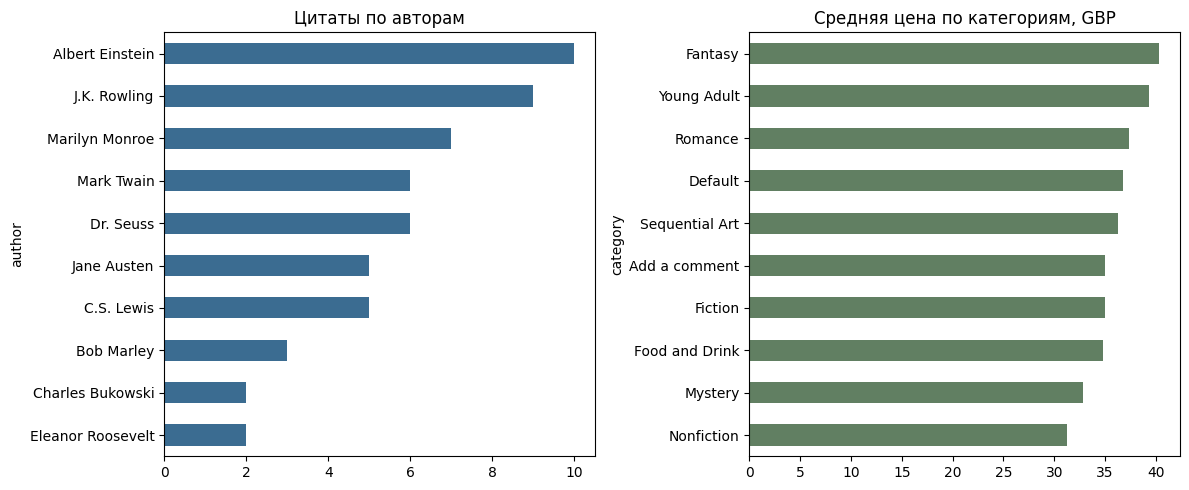

In [3]:
authors = pd.DataFrame(report['aggregates']['quotes_by_author']).head(10)
categories = pd.DataFrame(report['aggregates']['price_by_category']).head(10)
display(categories)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
authors.sort_values('quotes').plot.barh(x='author', y='quotes', ax=axes[0], legend=False, color='#3b6c91')
axes[0].set_title('Цитаты по авторам')
categories.sort_values('average_price').plot.barh(x='category', y='average_price', ax=axes[1], legend=False, color='#617f62')
axes[1].set_title('Средняя цена по категориям, GBP')
fig.tight_layout()
Path('figures').mkdir(exist_ok=True)
fig.savefig('figures/aggregates.png', dpi=160)
plt.show()

## JOBDIR и HTTP-кэш

In [4]:
runs = pd.DataFrame(report['runs'])
display(runs[['run', 'items', 'written', 'duration_s', 'requests', 'cache_store', 'cache_hit', 'dupefilter_filtered']])
assert runs.loc[runs['run'].eq('resume_2'), 'dupefilter_filtered'].iloc[0] >= 1
assert runs.loc[runs['run'].eq('cache_2'), 'cache_hit'].iloc[0] > 0

,run,items,written,duration_s,requests,cache_store,cache_hit,dupefilter_filtered
0,books_full,304,304,10.906,0,0,326,0
1,cache_1,100,100,36.781,114,114,97,0
2,cache_2,100,100,2.750,0,0,211,0
3,resume_1,35,35,20.078,58,58,25,0
4,resume_2,65,65,18.516,56,56,73,1


## Smoke-check и результат n8n

In [5]:
previous = json.loads(Path('previous.json').read_text(encoding='utf-8'))
assert check(previous, report) == []
quotes = pd.read_csv('quotes.csv')
nocode = pd.read_csv('../nocode/nocode_result.csv')
nocode['quote'] = nocode['quote'].str.replace(r'\s+', ' ', regex=True).str.strip()
joined = nocode.merge(quotes, on=['quote','author'], suffixes=('_n8n','_scrapy'), validate='one_to_one')
assert len(nocode) >= 30
assert len(joined) == len(nocode)
for field in ['birth_date','birth_place','biography']:
    assert joined[field+'_n8n'].eq(joined[field+'_scrapy']).all()
display(nocode[['author','quote']].head())
print('Smoke-check: OK; совпадений с n8n:', len(joined))

,author,quote
0,Marilyn Monroe,“This life is what you make it. No matter what...
1,J.K. Rowling,“It takes a great deal of bravery to stand up ...
2,Albert Einstein,"“If you can't explain it to a six year old, yo..."
3,Bob Marley,"“You may not be her first, her last, or her on..."
4,Dr. Seuss,"“I like nonsense, it wakes up the brain cells...."


Smoke-check: OK; совпадений с n8n: 30
